#### Code to generate the figures in the paper

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

#### Main results figure

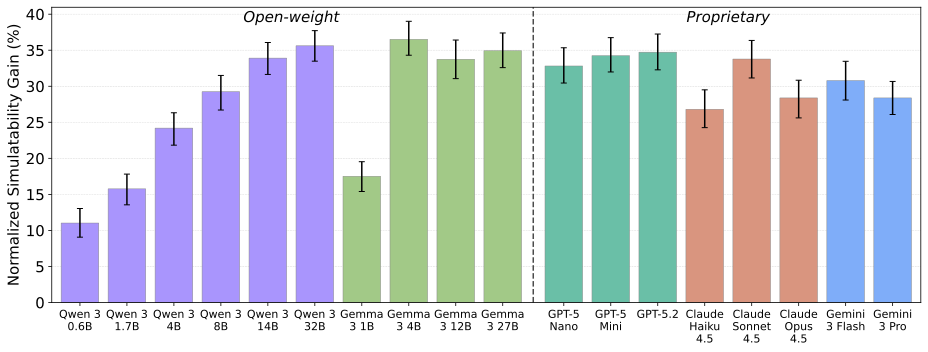

In [2]:
###################################################################################################
# normalised simulatability gain
# main result: gpt-5, claude 4.5, gemini 3, qwen 3, gemma 3 (llama dropped). Get main dataset
###################################################################################################
# import the results files
families = ['gpt_5', 'claude_4_5', 'gemini_3', 'qwen_3', 'gemma_3']

# Model name mapping (internal -> display)
name_dict = {
    "openai/gpt-5-mini_medium": "GPT-5 Mini",
    "openai/gpt-5-nano_medium": "GPT-5 Nano",
    "openai/gpt-5.2_medium": "GPT-5.2",
    "anthropic/claude-haiku-4.5_medium": "Claude Haiku 4.5",
    "anthropic/claude-opus-4.5_medium": "Claude Opus 4.5",
    "anthropic/claude-sonnet-4.5_medium": "Claude Sonnet 4.5",
    "google/gemini-3-flash-preview_medium": "Gemini 3 Flash",
    "google/gemini-3-pro-preview_medium": "Gemini 3 Pro",
    "Qwen/Qwen3-0.6B_True": "Qwen 3 0.6B",
    "Qwen/Qwen3-1.7B_True": "Qwen 3 1.7B",
    "Qwen/Qwen3-14B_True": "Qwen 3 14B",
    "Qwen/Qwen3-32B_True": "Qwen 3 32B",
    "Qwen/Qwen3-4B_True": "Qwen 3 4B",
    "Qwen/Qwen3-8B_True": "Qwen 3 8B",
    "google/gemma-3-12b-it": "Gemma 3 12B",
    "google/gemma-3-1b-it": "Gemma 3 1B",
    "google/gemma-3-27b-it": "Gemma 3 27B",
    "google/gemma-3-4b-it": "Gemma 3 4B",
}

# Family display names (internal -> display)
family_display_names = {
    'qwen_3': 'Qwen 3',
    'gemma_3': 'Gemma 3',
    'gpt_5': 'GPT-5',
    'claude_4_5': 'Claude 4.5',
    'gemini_3': 'Gemini 3',
}

# Helper function to lighten a hex color
def lighten_color(hex_color, factor=0.4):
    """Lighten a hex color by blending with white. factor=0 is original, factor=1 is white."""
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f'#{r:02x}{g:02x}{b:02x}'

# Original brand colors
original_colors = {
    'qwen_3': '#7C5CFC', 
    'gemma_3': '#70AD47',     
    'gpt_5': '#1B9D79', 
    'claude_4_5': '#C65D3B', 
    'gemini_3': '#3B82F6', 
}

# Lightened versions for the plot
lighten_factor = 0.35  # Adjust this: 0 = original, 1 = white
family_colors = {k: lighten_color(v, lighten_factor) for k, v in original_colors.items()}

# Figure parameters
fig_width = 13
fig_height = 5
y_label_fontsize = 15
x_label_fontsize = 11
section_label_fontsize = 15
show_grid = True
horizontal_labels = True  # If True, labels are horizontal with line breaks; if False, rotated 45 degrees

d = {}
for f in families: # gemini_3_predictions_simulatability_averaged
    df_ = pd.read_csv(f"../experiments/dewi_upload/{f}_predictions_simulatability_averaged.csv")
    df_['family'] = f
    d.update({f:df_})

# combine
df = pd.concat(d.values())
df['short_name'] = df['model'].map(name_dict)

# Multi-line versions of names for horizontal labels
def make_multiline(name):
    if name.startswith('Claude'):
        return name.replace(' ', '\n')  # split all spaces (3 lines)
    elif name.startswith('Qwen'):
        return '\n'.join(name.rsplit(' ', 1))  # split after 3 (last space)
    elif name.startswith('Gemma'):
        return name.replace(' ', '\n', 1)  # split after Gemma (first space)
    elif name.startswith('Gemini'):
        return name.replace(' ', '\n', 1)  # split after Gemini (first space)
    else:
        return '\n'.join(name.rsplit(' ', 1))  # GPT: split at last space

name_dict_multiline = {k: make_multiline(v) for k, v in name_dict.items()}
df['short_name_multiline'] = df['model'].map(name_dict_multiline)

custom_order = [
    # Open-weight models first
    # Qwen 3 family (by size, largest first)
    "Qwen 3 0.6B",
    "Qwen 3 1.7B",
    "Qwen 3 4B",
    "Qwen 3 8B",
    "Qwen 3 14B",
    "Qwen 3 32B",
    # Gemma 3 family (by size, largest first)
    "Gemma 3 1B",
    "Gemma 3 4B",
    "Gemma 3 12B",
    "Gemma 3 27B",
    # Closed-weight models
    # GPT-5 family
    "GPT-5 Nano",
    "GPT-5 Mini",
    "GPT-5.2",
    # Claude 4.5 family
    "Claude Haiku 4.5",
    "Claude Sonnet 4.5",
    "Claude Opus 4.5",
    # Gemini 3 family
    "Gemini 3 Flash",
    "Gemini 3 Pro",
]

custom_order_multiline = [make_multiline(name) for name in custom_order]

# Create a categorical type with the custom order
df['short_name'] = pd.Categorical(df['short_name'], categories=custom_order, ordered=True)
df['short_name_multiline'] = pd.Categorical(df['short_name_multiline'], categories=custom_order_multiline, ordered=True)

# Sort by the custom order
df = df.sort_values('short_name').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Calculate error bar sizes (distance from the mean)
yerr_lower = df['normalized_gain'] - df['norm_gain_ci_lower']
yerr_upper = df['norm_gain_ci_upper'] - df['normalized_gain']

# Create custom x positions with a gap between open and closed models
# Open models: indices 0-9 (10 models), Closed models: indices 10-17 (8 models)
n_open = 10
gap_size = 0.3  # Size of gap between open and closed sections
x_positions = []
for i in range(len(df)):
    if i < n_open:
        x_positions.append(i)
    else:
        x_positions.append(i + gap_size)
df['x_pos'] = x_positions

# Plot bars with family colours using custom x positions
for family in df['family'].unique():
    mask = df['family'] == family
    ax.bar(df.loc[mask, 'x_pos'], df.loc[mask, 'normalized_gain'],
           yerr=[yerr_lower[mask], yerr_upper[mask]],
           capsize=3,
           color=family_colors[family],
           edgecolor='#888888',
           linewidth=0.5,
           label=family_display_names[family])

# Add optional horizontal grid lines
if show_grid:
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='gray')
    ax.set_axisbelow(True)  # Grid lines behind bars

# Add vertical dashed line between open and closed models
divider_x = n_open - 0.5 + gap_size / 2
ax.axvline(x=divider_x, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Set x-axis ticks and labels
ax.set_xticks(df['x_pos'])
if horizontal_labels:
    ax.set_xticklabels(df['short_name_multiline'], rotation=0, ha='center', fontsize=x_label_fontsize)
else:
    ax.set_xticklabels(df['short_name'], rotation=45, ha='right', fontsize=x_label_fontsize)

# Remove whitespace before first bar and after last bar
ax.set_xlim(-0.6, max(x_positions) + 0.6)

# Add text labels for open/closed sections
ylim = ax.get_ylim()
ax.text((n_open - 1) / 2, ylim[1] * 0.95, 'Open-weight', ha='center', fontsize=section_label_fontsize, fontstyle='italic')
ax.text(n_open + gap_size + (len(df) - n_open - 1) / 2, ylim[1] * 0.95, 'Proprietary', ha='center', fontsize=section_label_fontsize, fontstyle='italic')

ax.tick_params(axis='y', labelsize=y_label_fontsize)
plt.ylabel('Normalized Simulatability Gain (%)', fontsize=y_label_fontsize)
plt.tight_layout()
plt.savefig('main_results.pdf', bbox_inches='tight')

Saved: nsg_predictor_breakdown_stacked.pdf


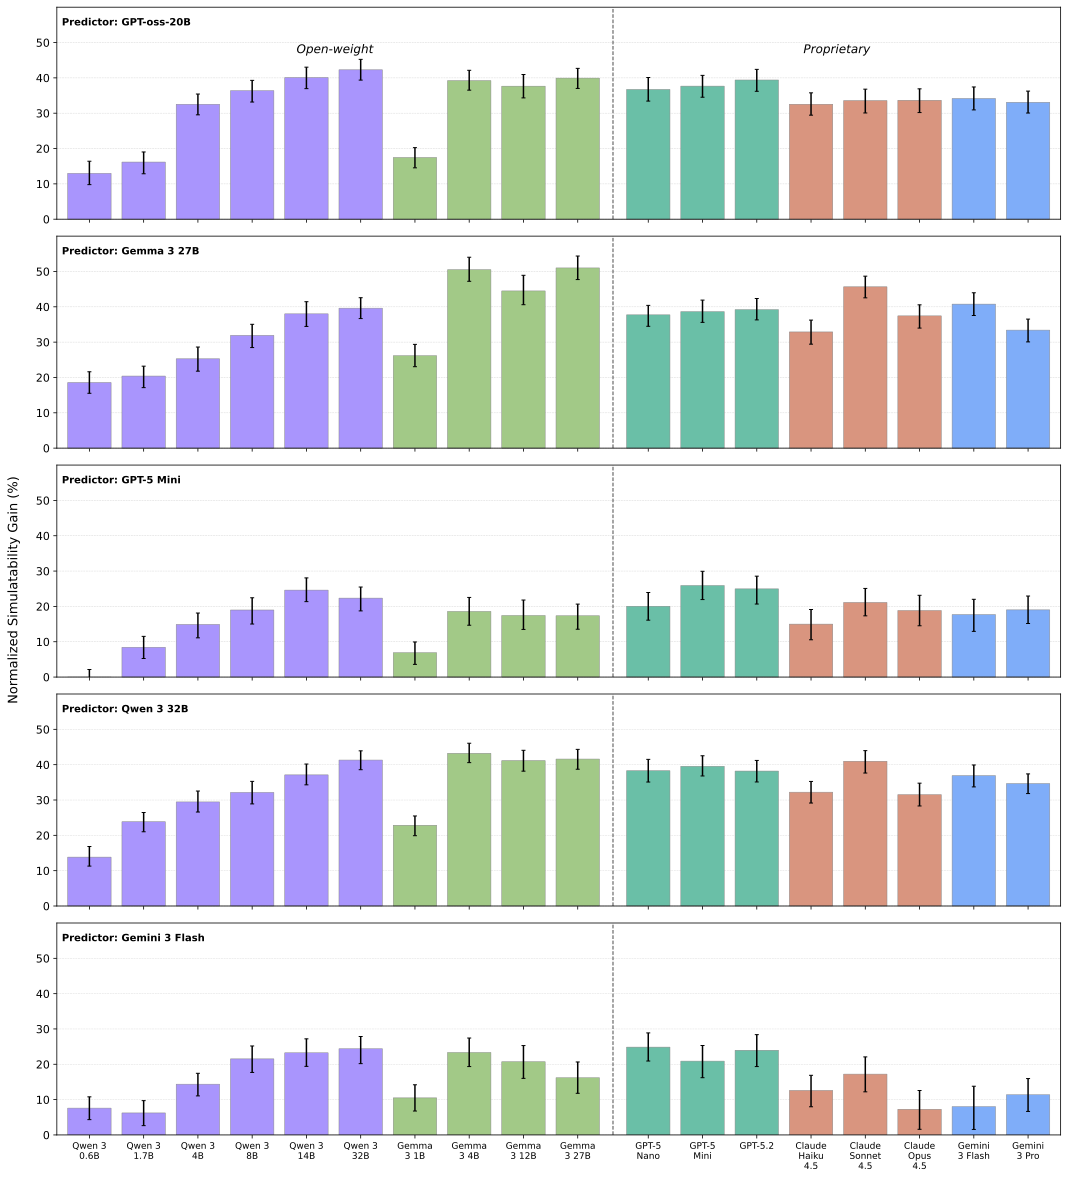

In [3]:
###################################################################################################
# normalised simulatability gain
# main result: gpt-5, claude 4.5, gemini 3, qwen 3, gemma 3 (llama dropped). Get main dataset
# BREAKDOWN BY PREDICTOR
###################################################################################################

# Load and prepare data (same as main figure)
families = ['gpt_5', 'claude_4_5', 'gemini_3', 'qwen_3', 'gemma_3']
name_dict = {
    "openai/gpt-5-mini_medium": "GPT-5 Mini",
    "openai/gpt-5-nano_medium": "GPT-5 Nano",
    "openai/gpt-5.2_medium": "GPT-5.2",
    "anthropic/claude-haiku-4.5_medium": "Claude Haiku 4.5",
    "anthropic/claude-opus-4.5_medium": "Claude Opus 4.5",
    "anthropic/claude-sonnet-4.5_medium": "Claude Sonnet 4.5",
    "google/gemini-3-flash-preview_medium": "Gemini 3 Flash",
    "google/gemini-3-pro-preview_medium": "Gemini 3 Pro",
    "Qwen/Qwen3-0.6B_True": "Qwen 3 0.6B",
    "Qwen/Qwen3-1.7B_True": "Qwen 3 1.7B",
    "Qwen/Qwen3-14B_True": "Qwen 3 14B",
    "Qwen/Qwen3-32B_True": "Qwen 3 32B",
    "Qwen/Qwen3-4B_True": "Qwen 3 4B",
    "Qwen/Qwen3-8B_True": "Qwen 3 8B",
    "google/gemma-3-12b-it": "Gemma 3 12B",
    "google/gemma-3-1b-it": "Gemma 3 1B",
    "google/gemma-3-27b-it": "Gemma 3 27B",
    "google/gemma-3-4b-it": "Gemma 3 4B",
}
family_display_names = {
    'qwen_3': 'Qwen 3', 'gemma_3': 'Gemma 3', 'gpt_5': 'GPT-5',
    'claude_4_5': 'Claude 4.5', 'gemini_3': 'Gemini 3',
}

# Predictor display names mapping
predictor_display_names = {
    'openai/gpt-oss-20b': 'GPT-oss-20B',
    'google/gemma-3-27b-it': 'Gemma 3 27B',
    'openai/gpt-5-mini': 'GPT-5 Mini',
    'Qwen/Qwen3-32B': 'Qwen 3 32B',
    'google/gemini-3-flash-preview': 'Gemini 3 Flash',
}

# Order for predictors (top to bottom)
predictor_order = [
    'openai/gpt-oss-20b',
    'google/gemma-3-27b-it', 
    'openai/gpt-5-mini',
    'Qwen/Qwen3-32B',
    'google/gemini-3-flash-preview',
]

def lighten_color(hex_color, factor=0.4):
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    return f'#{int(r + (255 - r) * factor):02x}{int(g + (255 - g) * factor):02x}{int(b + (255 - b) * factor):02x}'

# Multi-line versions of names for horizontal labels
def make_multiline(name):
    if name.startswith('Claude'):
        return name.replace(' ', '\n')
    elif name.startswith('Qwen'):
        return '\n'.join(name.rsplit(' ', 1))
    elif name.startswith('Gemma'):
        return name.replace(' ', '\n', 1)
    elif name.startswith('Gemini'):
        return name.replace(' ', '\n', 1)
    else:
        return '\n'.join(name.rsplit(' ', 1))

name_dict_multiline = {k: make_multiline(v) for k, v in name_dict.items()}

original_colors = {'qwen_3': '#7C5CFC', 'gemma_3': '#70AD47', 'gpt_5': '#1B9D79', 'claude_4_5': '#C65D3B', 'gemini_3': '#3B82F6'}
family_colors = {k: lighten_color(v, 0.35) for k, v in original_colors.items()}

# Load breakdown data for all families
all_breakdown_data = []
for f in families:
    df_ = pd.read_csv(f"../experiments/dewi_upload/{f}_predictions_simulatability_breakdown_by_predictor.csv")
    df_['family'] = f
    all_breakdown_data.append(df_)

df_breakdown = pd.concat(all_breakdown_data, ignore_index=True)
df_breakdown['short_name'] = df_breakdown['model'].map(name_dict)
df_breakdown['short_name_multiline'] = df_breakdown['model'].map(name_dict_multiline)

# Custom order for models
custom_order = [
    "Qwen 3 0.6B", "Qwen 3 1.7B", "Qwen 3 4B", "Qwen 3 8B", "Qwen 3 14B", "Qwen 3 32B",
    "Gemma 3 1B", "Gemma 3 4B", "Gemma 3 12B", "Gemma 3 27B",
    "GPT-5 Nano", "GPT-5 Mini", "GPT-5.2",
    "Claude Haiku 4.5", "Claude Sonnet 4.5", "Claude Opus 4.5",
    "Gemini 3 Flash", "Gemini 3 Pro",
]
custom_order_multiline = [make_multiline(name) for name in custom_order]

# Figure parameters - wider, tightly packed
# These dimensions are perfect: DO NOT TOUCH
fig_width = 15
subplot_height = 3
n_predictors = len(predictor_order)
fig_height = subplot_height * n_predictors + 1.5  # Extra space for x-labels at bottom

# Make this larger
y_label_fontsize = 11
x_label_fontsize = 9
section_label_fontsize = 12
predictor_label_fontsize = 10
show_grid = True
show_error_bars = True
n_open = 10
gap_size = 0.3

# Create stacked subplots
fig, axes = plt.subplots(n_predictors, 1, figsize=(fig_width, fig_height), sharex=True)

for idx, predictor in enumerate(predictor_order):
    ax = axes[idx]
    
    # Filter data for this predictor
    df_pred = df_breakdown[df_breakdown['predictor'] == predictor].copy()
    
    # Apply categorical ordering
    df_pred['short_name'] = pd.Categorical(df_pred['short_name'], categories=custom_order, ordered=True)
    df_pred['short_name_multiline'] = pd.Categorical(df_pred['short_name_multiline'], categories=custom_order_multiline, ordered=True)
    df_pred = df_pred.sort_values('short_name').reset_index(drop=True)
    
    # Create x positions with gap
    x_positions = [i if i < n_open else i + gap_size for i in range(len(df_pred))]
    df_pred['x_pos'] = x_positions
    
    # Calculate error bar sizes (distance from the mean)
    yerr_lower = df_pred['normalized_gain'] - df_pred['norm_gain_ci_lower']
    yerr_upper = df_pred['norm_gain_ci_upper'] - df_pred['normalized_gain']
    
    # Plot bars with family colours
    for family in df_pred['family'].unique():
        mask = df_pred['family'] == family
        ax.bar(df_pred.loc[mask, 'x_pos'], df_pred.loc[mask, 'normalized_gain'],
               yerr=[yerr_lower[mask], yerr_upper[mask]] if show_error_bars else None,
               capsize=2 if show_error_bars else 0,
               color=family_colors[family],
               edgecolor='#888888',
               linewidth=0.5)
    
    if show_grid:
        ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='gray')
        ax.set_axisbelow(True)
    
    # Vertical divider line
    divider_x = n_open - 0.5 + gap_size / 2
    ax.axvline(x=divider_x, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
    
    ax.set_xlim(-0.6, max(x_positions) + 0.6)
    ax.set_ylim(0, 60)
    ax.set_yticks([0, 10, 20, 30, 40, 50])
    ax.tick_params(axis='y', labelsize=y_label_fontsize)
    
    # Predictor label - always top LEFT
    predictor_display = predictor_display_names.get(predictor, predictor)
    ax.text(0.005, 0.95, f'Predictor: {predictor_display}', transform=ax.transAxes, fontsize=predictor_label_fontsize,
            ha='left', va='top', fontweight='bold')
    
    # Only add section labels and legend on top subplot
    if idx == 0:
        # Open-weight label: centered between left edge (-0.6) and divider
        open_weight_center = (-0.6 + divider_x) / 2
        ax.text(open_weight_center, 47, 'Open-weight', ha='center', fontsize=section_label_fontsize, fontstyle='italic')
        
        # Proprietary label: centered between divider and right edge
        prop_center = (divider_x + max(x_positions) + 0.6) / 2
        ax.text(prop_center, 47, 'Proprietary', ha='center', fontsize=section_label_fontsize, fontstyle='italic')
    
    # Hide x-tick labels for all but bottom subplot
    if idx < n_predictors - 1:
        ax.tick_params(axis='x', labelbottom=False)

# X-axis labels only on bottom subplot
axes[-1].set_xticks(x_positions)
axes[-1].set_xticklabels(df_pred['short_name_multiline'], rotation=0, ha='center', fontsize=x_label_fontsize)

# Shared y-axis label
fig.text(0.02, 0.5, 'Normalized Simulatability Gain (%)', va='center', ha='center', 
         rotation='vertical', fontsize=y_label_fontsize + 2)

plt.tight_layout()
plt.subplots_adjust(left=0.06, hspace=0.08)  # Tight vertical spacing
plt.savefig('nsg_predictor_breakdown_stacked.pdf', bbox_inches='tight')
print("Saved: nsg_predictor_breakdown_stacked.pdf")

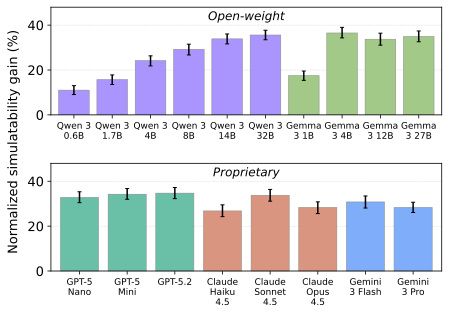

In [4]:
###################################################################################################
### VERSION 2 - Stacked subplots (Open-weight / Proprietary) to match ITC figure
###################################################################################################
families = ['gpt_5', 'claude_4_5', 'gemini_3', 'qwen_3', 'gemma_3']

# Model name mapping (internal -> display)
name_dict = {
    "openai/gpt-5-mini_medium": "GPT-5 Mini",
    "openai/gpt-5-nano_medium": "GPT-5 Nano",
    "openai/gpt-5.2_medium": "GPT-5.2",
    "anthropic/claude-haiku-4.5_medium": "Claude Haiku 4.5",
    "anthropic/claude-opus-4.5_medium": "Claude Opus 4.5",
    "anthropic/claude-sonnet-4.5_medium": "Claude Sonnet 4.5",
    "google/gemini-3-flash-preview_medium": "Gemini 3 Flash",
    "google/gemini-3-pro-preview_medium": "Gemini 3 Pro",
    "Qwen/Qwen3-0.6B_True": "Qwen 3 0.6B",
    "Qwen/Qwen3-1.7B_True": "Qwen 3 1.7B",
    "Qwen/Qwen3-14B_True": "Qwen 3 14B",
    "Qwen/Qwen3-32B_True": "Qwen 3 32B",
    "Qwen/Qwen3-4B_True": "Qwen 3 4B",
    "Qwen/Qwen3-8B_True": "Qwen 3 8B",
    "google/gemma-3-12b-it": "Gemma 3 12B",
    "google/gemma-3-1b-it": "Gemma 3 1B",
    "google/gemma-3-27b-it": "Gemma 3 27B",
    "google/gemma-3-4b-it": "Gemma 3 4B",
}

# Family display names
family_display_names = {
    'qwen_3': 'Qwen 3',
    'gemma_3': 'Gemma 3',
    'gpt_5': 'GPT-5',
    'claude_4_5': 'Claude 4.5',
    'gemini_3': 'Gemini 3',
}

def lighten_color(hex_color, factor=0.4):
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f'#{r:02x}{g:02x}{b:02x}'

original_colors = {
    'qwen_3': '#7C5CFC', 
    'gemma_3': '#70AD47',     
    'gpt_5': '#1B9D79', 
    'claude_4_5': '#C65D3B', 
    'gemini_3': '#3B82F6', 
}
lighten_factor = 0.35
family_colors = {k: lighten_color(v, lighten_factor) for k, v in original_colors.items()}

# Multi-line versions of names for horizontal labels
def make_multiline(name):
    if name.startswith('Claude'):
        return name.replace(' ', '\n')
    elif name.startswith('Qwen'):
        return '\n'.join(name.rsplit(' ', 1))
    elif name.startswith('Gemma'):
        return name.replace(' ', '\n', 1)
    elif name.startswith('Gemini'):
        return name.replace(' ', '\n', 1)
    else:
        return '\n'.join(name.rsplit(' ', 1))

name_dict_multiline = {k: make_multiline(v) for k, v in name_dict.items()}

# Load data
d = {}
for f in families:
    df_ = pd.read_csv(f"../experiments/dewi_upload/{f}_predictions_simulatability_averaged.csv")
    df_['family'] = f
    d.update({f: df_})

df = pd.concat(d.values())
df['short_name'] = df['model'].map(name_dict)
df['short_name_multiline'] = df['model'].map(name_dict_multiline)

# Define orders
open_weight_order = [
    "Qwen 3 0.6B", "Qwen 3 1.7B", "Qwen 3 4B", "Qwen 3 8B", "Qwen 3 14B", "Qwen 3 32B",
    "Gemma 3 1B", "Gemma 3 4B", "Gemma 3 12B", "Gemma 3 27B",
]
open_weight_order_multiline = [make_multiline(name) for name in open_weight_order]

proprietary_order = [
    "GPT-5 Nano", "GPT-5 Mini", "GPT-5.2",
    "Claude Haiku 4.5", "Claude Sonnet 4.5", "Claude Opus 4.5",
    "Gemini 3 Flash", "Gemini 3 Pro",
]
proprietary_order_multiline = [make_multiline(name) for name in proprietary_order]

# Split data
df_open = df[df['short_name'].isin(open_weight_order)].copy()
df_open['short_name'] = pd.Categorical(df_open['short_name'], categories=open_weight_order, ordered=True)
df_open['short_name_multiline'] = pd.Categorical(df_open['short_name_multiline'], categories=open_weight_order_multiline, ordered=True)
df_open = df_open.sort_values('short_name').reset_index(drop=True)

df_prop = df[df['short_name'].isin(proprietary_order)].copy()
df_prop['short_name'] = pd.Categorical(df_prop['short_name'], categories=proprietary_order, ordered=True)
df_prop['short_name_multiline'] = pd.Categorical(df_prop['short_name_multiline'], categories=proprietary_order_multiline, ordered=True)
df_prop = df_prop.sort_values('short_name').reset_index(drop=True)

# Figure parameters - match ITC figure
fig_width = 6.5
fig_height = 4.5
y_label_fontsize = 13
x_label_fontsize = 9
label_fontsize = 12
show_grid = True

# Create stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_width, fig_height), sharex=False)

# Shared y-axis limits - start at 0
y_min, y_max = 0, 48

# --- Top subplot: Open-weight models ---
yerr_lower = df_open['normalized_gain'] - df_open['norm_gain_ci_lower']
yerr_upper = df_open['norm_gain_ci_upper'] - df_open['normalized_gain']

for family in df_open['family'].unique():
    mask = df_open['family'] == family
    x_pos = df_open.loc[mask].index.tolist()
    ax1.bar(x_pos, df_open.loc[mask, 'normalized_gain'],
            yerr=[yerr_lower[mask], yerr_upper[mask]],
            capsize=2, color=family_colors[family], edgecolor='#888888', linewidth=0.5,
            label=family_display_names[family])

ax1.set_xticks(range(len(df_open)))
ax1.set_xticklabels(df_open['short_name_multiline'], rotation=0, ha='center', fontsize=x_label_fontsize)
ax1.set_xlim(-0.6, len(df_open) - 0.4)
ax1.set_ylim(y_min, y_max)
ax1.tick_params(axis='y', labelsize=y_label_fontsize)
if show_grid:
    ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='gray')
    ax1.set_axisbelow(True)
ax1.text(0.5, 0.88, 'Open-weight', ha='center', transform=ax1.transAxes, fontsize=label_fontsize, fontstyle='italic')

# --- Bottom subplot: Proprietary models ---
yerr_lower = df_prop['normalized_gain'] - df_prop['norm_gain_ci_lower']
yerr_upper = df_prop['norm_gain_ci_upper'] - df_prop['normalized_gain']

for family in df_prop['family'].unique():
    mask = df_prop['family'] == family
    x_pos = df_prop.loc[mask].index.tolist()
    ax2.bar(x_pos, df_prop.loc[mask, 'normalized_gain'],
            yerr=[yerr_lower[mask], yerr_upper[mask]],
            capsize=2, color=family_colors[family], edgecolor='#888888', linewidth=0.5,
            label=family_display_names[family])

ax2.set_xticks(range(len(df_prop)))
ax2.set_xticklabels(df_prop['short_name_multiline'], rotation=0, ha='center', fontsize=x_label_fontsize)
ax2.set_xlim(-0.6, len(df_prop) - 0.4)
ax2.set_ylim(y_min, y_max)
ax2.tick_params(axis='y', labelsize=y_label_fontsize)
if show_grid:
    ax2.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='gray')
    ax2.set_axisbelow(True)
ax2.text(0.5, 0.88, 'Proprietary', ha='center', transform=ax2.transAxes, fontsize=label_fontsize, fontstyle='italic')

# Shared y-axis label (like ITC figure)
fig.text(0.06, 0.55, 'Normalized simulatability gain (%)', va='center', ha='center', 
         rotation='vertical', fontsize=y_label_fontsize)

plt.tight_layout()
plt.subplots_adjust(left=0.14, hspace=0.45)
plt.savefig('main_results_v2.pdf', bbox_inches='tight')

#### Accuracy comparison figure (WITH vs WITHOUT explanation)

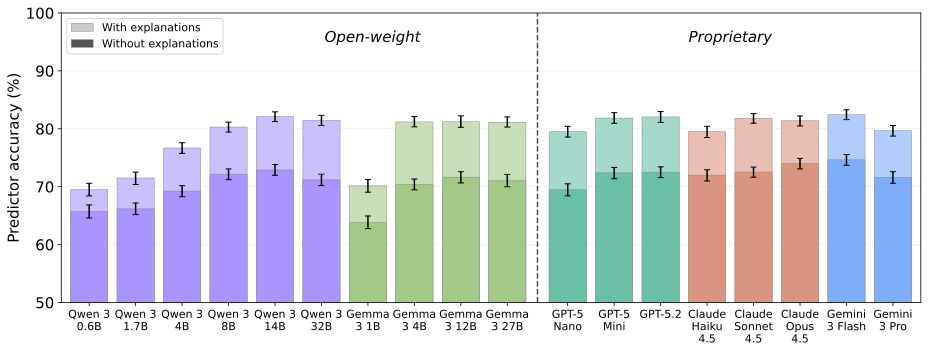

In [10]:
########################################################################
# Accuracy comparison figure: WITH vs WITHOUT explanation accuracy
# Self-contained cell - loads its own data
########################################################################


# Load and prepare data (same as main figure)
families = ['gpt_5', 'claude_4_5', 'gemini_3', 'qwen_3', 'gemma_3']
name_dict = {
    "openai/gpt-5-mini_medium": "GPT-5 Mini",
    "openai/gpt-5-nano_medium": "GPT-5 Nano",
    "openai/gpt-5.2_medium": "GPT-5.2",
    "anthropic/claude-haiku-4.5_medium": "Claude Haiku 4.5",
    "anthropic/claude-opus-4.5_medium": "Claude Opus 4.5",
    "anthropic/claude-sonnet-4.5_medium": "Claude Sonnet 4.5",
    "google/gemini-3-flash-preview_medium": "Gemini 3 Flash",
    "google/gemini-3-pro-preview_medium": "Gemini 3 Pro",
    "Qwen/Qwen3-0.6B_True": "Qwen 3 0.6B",
    "Qwen/Qwen3-1.7B_True": "Qwen 3 1.7B",
    "Qwen/Qwen3-14B_True": "Qwen 3 14B",
    "Qwen/Qwen3-32B_True": "Qwen 3 32B",
    "Qwen/Qwen3-4B_True": "Qwen 3 4B",
    "Qwen/Qwen3-8B_True": "Qwen 3 8B",
    "google/gemma-3-12b-it": "Gemma 3 12B",
    "google/gemma-3-1b-it": "Gemma 3 1B",
    "google/gemma-3-27b-it": "Gemma 3 27B",
    "google/gemma-3-4b-it": "Gemma 3 4B",
}
family_display_names = {
    'qwen_3': 'Qwen 3', 'gemma_3': 'Gemma 3', 'gpt_5': 'GPT-5',
    'claude_4_5': 'Claude 4.5', 'gemini_3': 'Gemini 3',
}

def lighten_color(hex_color, factor=0.4):
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    return f'#{int(r + (255 - r) * factor):02x}{int(g + (255 - g) * factor):02x}{int(b + (255 - b) * factor):02x}'

# Multi-line versions of names for horizontal labels
def make_multiline(name):
    if name.startswith('Claude'):
        return name.replace(' ', '\n')  # split all spaces (3 lines)
    elif name.startswith('Qwen'):
        return '\n'.join(name.rsplit(' ', 1))  # split after 3 (last space)
    elif name.startswith('Gemma'):
        return name.replace(' ', '\n', 1)  # split after Gemma (first space)
    elif name.startswith('Gemini'):
        return name.replace(' ', '\n', 1)  # split after Gemini (first space)
    else:
        return '\n'.join(name.rsplit(' ', 1))  # GPT: split at last space

name_dict_multiline = {k: make_multiline(v) for k, v in name_dict.items()}

original_colors = {'qwen_3': '#7C5CFC', 'gemma_3': '#70AD47', 'gpt_5': '#1B9D79', 'claude_4_5': '#C65D3B', 'gemini_3': '#3B82F6'}
family_colors = {k: lighten_color(v, 0.35) for k, v in original_colors.items()}

d = {}
for f in families:
    df_ = pd.read_csv(f"../experiments/dewi_upload/{f}_predictions_simulatability_averaged.csv")
    df_['family'] = f
    d[f] = df_
df_acc = pd.concat(d.values())
df_acc['short_name'] = df_acc['model'].map(name_dict)
df_acc['short_name_multiline'] = df_acc['model'].map(name_dict_multiline)

custom_order = [
    "Qwen 3 0.6B", "Qwen 3 1.7B", "Qwen 3 4B", "Qwen 3 8B", "Qwen 3 14B", "Qwen 3 32B",
    "Gemma 3 1B", "Gemma 3 4B", "Gemma 3 12B", "Gemma 3 27B",
    "GPT-5 Nano", "GPT-5 Mini", "GPT-5.2",
    "Claude Haiku 4.5", "Claude Sonnet 4.5", "Claude Opus 4.5",
    "Gemini 3 Flash", "Gemini 3 Pro",
]
custom_order_multiline = [make_multiline(name) for name in custom_order]

df_acc['short_name'] = pd.Categorical(df_acc['short_name'], categories=custom_order, ordered=True)
df_acc['short_name_multiline'] = pd.Categorical(df_acc['short_name_multiline'], categories=custom_order_multiline, ordered=True)
df_acc = df_acc.sort_values('short_name').reset_index(drop=True)

# Create x positions with gap
n_open = 10
gap_size = 0.3
x_positions = [i if i < n_open else i + gap_size for i in range(len(df_acc))]
df_acc['x_pos'] = x_positions

# Figure parameters
fig_width = 13
fig_height = 5
y_label_fontsize = 15
x_label_fontsize = 11
section_label_fontsize = 15
show_grid = True
show_error_bars = True

family_colors_light = {k: lighten_color(v, 0.4) for k, v in family_colors.items()}

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Plot WITH explanation accuracy (background - lighter bars)
for family in df_acc['family'].unique():
    mask = df_acc['family'] == family
    if show_error_bars:
        yerr_with = [df_acc.loc[mask, 'with_explanation_accuracy'] - df_acc.loc[mask, 'with_ci_lower'],
                     df_acc.loc[mask, 'with_ci_upper'] - df_acc.loc[mask, 'with_explanation_accuracy']]
    else:
        yerr_with = None
    ax.bar(df_acc.loc[mask, 'x_pos'], df_acc.loc[mask, 'with_explanation_accuracy'],
           yerr=yerr_with, capsize=3 if show_error_bars else 0,
           color=family_colors_light[family], edgecolor='#888888', linewidth=0.5)

# Plot WITHOUT explanation accuracy (foreground - darker bars)
for family in df_acc['family'].unique():
    mask = df_acc['family'] == family
    if show_error_bars:
        yerr_without = [df_acc.loc[mask, 'without_explanation_accuracy'] - df_acc.loc[mask, 'without_ci_lower'],
                        df_acc.loc[mask, 'without_ci_upper'] - df_acc.loc[mask, 'without_explanation_accuracy']]
    else:
        yerr_without = None
    ax.bar(df_acc.loc[mask, 'x_pos'], df_acc.loc[mask, 'without_explanation_accuracy'],
           yerr=yerr_without, capsize=3 if show_error_bars else 0,
           color=family_colors[family], edgecolor='#888888', linewidth=0.5)

if show_grid:
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='gray')
    ax.set_axisbelow(True)

ax.axvline(x=n_open - 0.5 + gap_size / 2, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xticks(df_acc['x_pos'])
ax.set_xticklabels(df_acc['short_name_multiline'], rotation=0, ha='center', fontsize=x_label_fontsize)

ax.set_xlim(-0.6, max(df_acc['x_pos']) + 0.6)

# Section labels
ylim = ax.get_ylim()

ax.set_ylim(50, 100)
ax.text((n_open - 1) / 2 + 1.6, 100* 0.95, 'Open-weight', ha='center', fontsize=section_label_fontsize, fontstyle='italic')
ax.text(n_open + gap_size + (len(df_acc) - n_open - 1) / 2, 100 * 0.95, 'Proprietary', ha='center', fontsize=section_label_fontsize, fontstyle='italic')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=lighten_color('#555555', 0.7), edgecolor='#888888', linewidth=0.5, label='With explanations'),
    Patch(facecolor='#555555', edgecolor='#888888', linewidth=0.5, label='Without explanations'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
ax.tick_params(axis='y', labelsize=y_label_fontsize)
plt.ylabel('Predictor accuracy (%)', fontsize=y_label_fontsize)
plt.tight_layout()
plt.savefig('accuracy_comparison.pdf', bbox_inches='tight')

Saved: predictor_breakdown_stacked.pdf


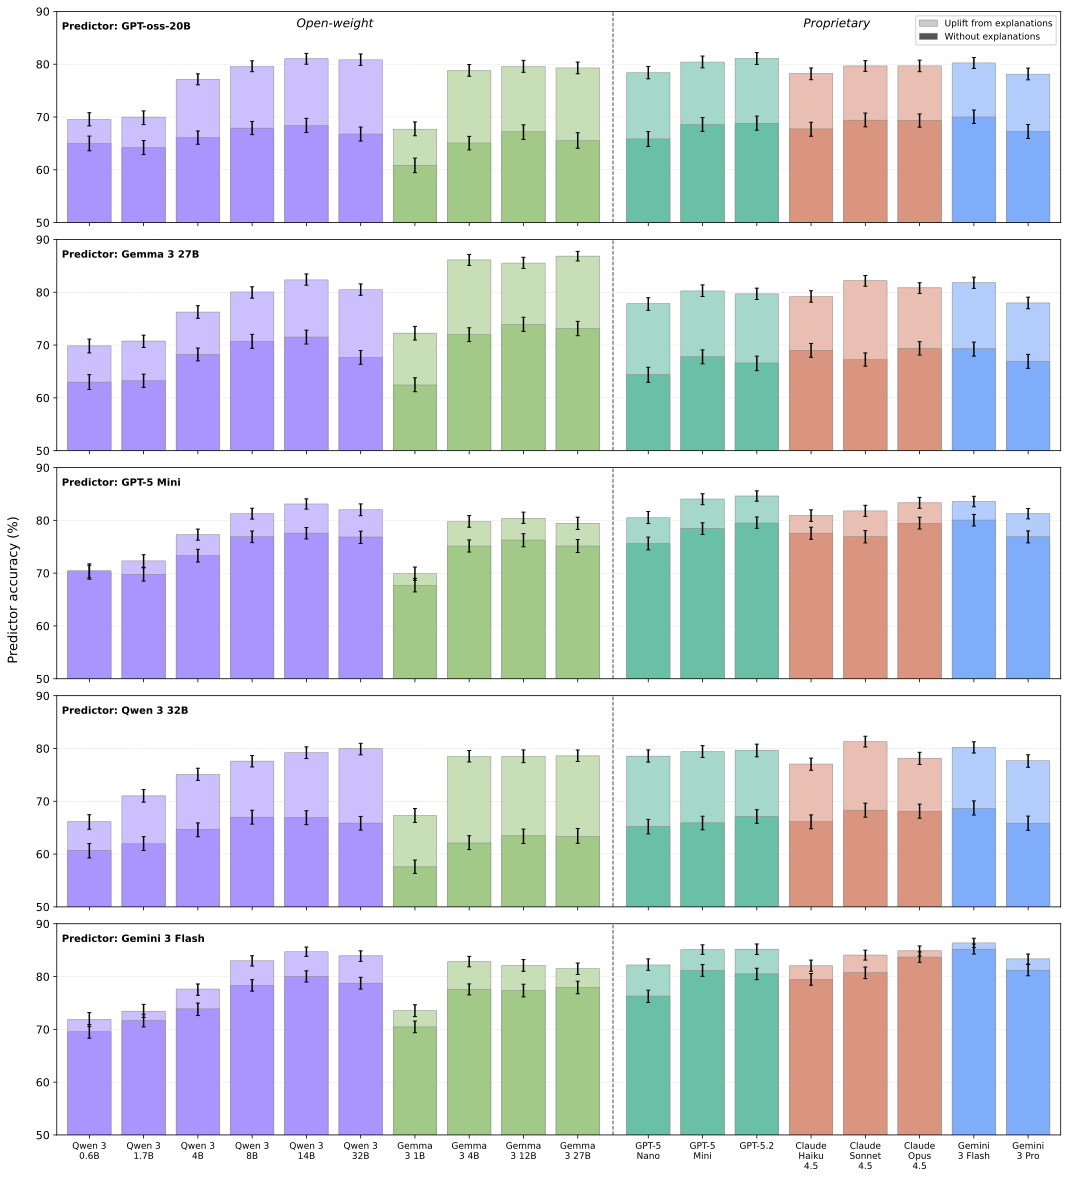

In [6]:
########################################################################
# Accuracy comparison figure: WITH vs WITHOUT explanation accuracy
# Self-contained cell - loads its own data
# BREAKDOWN BY PREDICTOR - Stacked subplots
########################################################################

# Load and prepare data (same as main figure)
families = ['gpt_5', 'claude_4_5', 'gemini_3', 'qwen_3', 'gemma_3']
name_dict = {
    "openai/gpt-5-mini_medium": "GPT-5 Mini",
    "openai/gpt-5-nano_medium": "GPT-5 Nano",
    "openai/gpt-5.2_medium": "GPT-5.2",
    "anthropic/claude-haiku-4.5_medium": "Claude Haiku 4.5",
    "anthropic/claude-opus-4.5_medium": "Claude Opus 4.5",
    "anthropic/claude-sonnet-4.5_medium": "Claude Sonnet 4.5",
    "google/gemini-3-flash-preview_medium": "Gemini 3 Flash",
    "google/gemini-3-pro-preview_medium": "Gemini 3 Pro",
    "Qwen/Qwen3-0.6B_True": "Qwen 3 0.6B",
    "Qwen/Qwen3-1.7B_True": "Qwen 3 1.7B",
    "Qwen/Qwen3-14B_True": "Qwen 3 14B",
    "Qwen/Qwen3-32B_True": "Qwen 3 32B",
    "Qwen/Qwen3-4B_True": "Qwen 3 4B",
    "Qwen/Qwen3-8B_True": "Qwen 3 8B",
    "google/gemma-3-12b-it": "Gemma 3 12B",
    "google/gemma-3-1b-it": "Gemma 3 1B",
    "google/gemma-3-27b-it": "Gemma 3 27B",
    "google/gemma-3-4b-it": "Gemma 3 4B",
}
family_display_names = {
    'qwen_3': 'Qwen 3', 'gemma_3': 'Gemma 3', 'gpt_5': 'GPT-5',
    'claude_4_5': 'Claude 4.5', 'gemini_3': 'Gemini 3',
}

# Predictor display names mapping
predictor_display_names = {
    'openai/gpt-oss-20b': 'GPT-oss-20B',
    'google/gemma-3-27b-it': 'Gemma 3 27B',
    'openai/gpt-5-mini': 'GPT-5 Mini',
    'Qwen/Qwen3-32B': 'Qwen 3 32B',
    'google/gemini-3-flash-preview': 'Gemini 3 Flash',
}

# Order for predictors (top to bottom)
predictor_order = [
    'openai/gpt-oss-20b',
    'google/gemma-3-27b-it', 
    'openai/gpt-5-mini',
    'Qwen/Qwen3-32B',
    'google/gemini-3-flash-preview',
]

def lighten_color(hex_color, factor=0.4):
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    return f'#{int(r + (255 - r) * factor):02x}{int(g + (255 - g) * factor):02x}{int(b + (255 - b) * factor):02x}'

# Multi-line versions of names for horizontal labels
def make_multiline(name):
    if name.startswith('Claude'):
        return name.replace(' ', '\n')
    elif name.startswith('Qwen'):
        return '\n'.join(name.rsplit(' ', 1))
    elif name.startswith('Gemma'):
        return name.replace(' ', '\n', 1)
    elif name.startswith('Gemini'):
        return name.replace(' ', '\n', 1)
    else:
        return '\n'.join(name.rsplit(' ', 1))

name_dict_multiline = {k: make_multiline(v) for k, v in name_dict.items()}

original_colors = {'qwen_3': '#7C5CFC', 'gemma_3': '#70AD47', 'gpt_5': '#1B9D79', 'claude_4_5': '#C65D3B', 'gemini_3': '#3B82F6'}
family_colors = {k: lighten_color(v, 0.35) for k, v in original_colors.items()}
family_colors_light = {k: lighten_color(v, 0.4) for k, v in family_colors.items()}

# Load breakdown data for all families
all_breakdown_data = []
for f in families:
    df_ = pd.read_csv(f"../experiments/dewi_upload/{f}_predictions_simulatability_breakdown_by_predictor.csv")
    df_['family'] = f
    all_breakdown_data.append(df_)

df_breakdown = pd.concat(all_breakdown_data, ignore_index=True)
df_breakdown['short_name'] = df_breakdown['model'].map(name_dict)
df_breakdown['short_name_multiline'] = df_breakdown['model'].map(name_dict_multiline)

# Custom order for models
custom_order = [
    "Qwen 3 0.6B", "Qwen 3 1.7B", "Qwen 3 4B", "Qwen 3 8B", "Qwen 3 14B", "Qwen 3 32B",
    "Gemma 3 1B", "Gemma 3 4B", "Gemma 3 12B", "Gemma 3 27B",
    "GPT-5 Nano", "GPT-5 Mini", "GPT-5.2",
    "Claude Haiku 4.5", "Claude Sonnet 4.5", "Claude Opus 4.5",
    "Gemini 3 Flash", "Gemini 3 Pro",
]
custom_order_multiline = [make_multiline(name) for name in custom_order]

# Figure parameters - wider, tightly packed
# These dimensions are perfect: DO NOT TOUCH
fig_width = 15
subplot_height = 3
n_predictors = len(predictor_order)
fig_height = subplot_height * n_predictors + 1.5  # Extra space for x-labels at bottom

# Make this larger
y_label_fontsize = 11
x_label_fontsize = 9
section_label_fontsize = 12
predictor_label_fontsize = 10
show_grid = True
show_error_bars = True
n_open = 10
gap_size = 0.3

# Create stacked subplots
fig, axes = plt.subplots(n_predictors, 1, figsize=(fig_width, fig_height), sharex=True)

for idx, predictor in enumerate(predictor_order):
    ax = axes[idx]
    
    # Filter data for this predictor
    df_pred = df_breakdown[df_breakdown['predictor'] == predictor].copy()
    
    # Apply categorical ordering
    df_pred['short_name'] = pd.Categorical(df_pred['short_name'], categories=custom_order, ordered=True)
    df_pred['short_name_multiline'] = pd.Categorical(df_pred['short_name_multiline'], categories=custom_order_multiline, ordered=True)
    df_pred = df_pred.sort_values('short_name').reset_index(drop=True)
    
    # Create x positions with gap
    x_positions = [i if i < n_open else i + gap_size for i in range(len(df_pred))]
    df_pred['x_pos'] = x_positions
    
    # Plot WITH explanation accuracy (background - lighter bars)
    for family in df_pred['family'].unique():
        mask = df_pred['family'] == family
        if show_error_bars:
            yerr_with = [df_pred.loc[mask, 'with_explanation_accuracy'] - df_pred.loc[mask, 'with_ci_lower'],
                         df_pred.loc[mask, 'with_ci_upper'] - df_pred.loc[mask, 'with_explanation_accuracy']]
        else:
            yerr_with = None
        ax.bar(df_pred.loc[mask, 'x_pos'], df_pred.loc[mask, 'with_explanation_accuracy'],
               yerr=yerr_with, capsize=2 if show_error_bars else 0,
               color=family_colors_light[family], edgecolor='#888888', linewidth=0.5)
    
    # Plot WITHOUT explanation accuracy (foreground - darker bars)
    for family in df_pred['family'].unique():
        mask = df_pred['family'] == family
        if show_error_bars:
            yerr_without = [df_pred.loc[mask, 'without_explanation_accuracy'] - df_pred.loc[mask, 'without_ci_lower'],
                            df_pred.loc[mask, 'without_ci_upper'] - df_pred.loc[mask, 'without_explanation_accuracy']]
        else:
            yerr_without = None
        ax.bar(df_pred.loc[mask, 'x_pos'], df_pred.loc[mask, 'without_explanation_accuracy'],
               yerr=yerr_without, capsize=2 if show_error_bars else 0,
               color=family_colors[family], edgecolor='#888888', linewidth=0.5)
    
    if show_grid:
        ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='gray')
        ax.set_axisbelow(True)
    
    # Vertical divider line
    divider_x = n_open - 0.5 + gap_size / 2
    ax.axvline(x=divider_x, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
    
    ax.set_xlim(-0.6, max(x_positions) + 0.6)
    ax.set_ylim(50, 90)
    ax.set_yticks([50, 60, 70, 80, 90])
    ax.tick_params(axis='y', labelsize=y_label_fontsize)
    
    # Predictor label - always top LEFT
    predictor_display = predictor_display_names.get(predictor, predictor)
    ax.text(0.005, 0.95, f'Predictor: {predictor_display}', transform=ax.transAxes, fontsize=predictor_label_fontsize,
            ha='left', va='top', fontweight='bold')
    
    # Only add section labels and legend on top subplot
    if idx == 0:
        # Open-weight label: centered between left edge (-0.6) and divider
        open_weight_center = (-0.6 + divider_x) / 2
        ax.text(open_weight_center, 87, 'Open-weight', ha='center', fontsize=section_label_fontsize, fontstyle='italic')
        
        # Proprietary label: centered between divider and right edge
        prop_center = (divider_x + max(x_positions) + 0.6) / 2
        ax.text(prop_center, 87, 'Proprietary', ha='center', fontsize=section_label_fontsize, fontstyle='italic')
        
        # Legend on top RIGHT
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=lighten_color('#555555', 0.7), edgecolor='#888888', linewidth=0.5, label='Uplift from explanations'),
            Patch(facecolor='#555555', edgecolor='#888888', linewidth=0.5, label='Without explanations'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.9)
    
    # Hide x-tick labels for all but bottom subplot
    if idx < n_predictors - 1:
        ax.tick_params(axis='x', labelbottom=False)

# X-axis labels only on bottom subplot
axes[-1].set_xticks(x_positions)
axes[-1].set_xticklabels(df_pred['short_name_multiline'], rotation=0, ha='center', fontsize=x_label_fontsize)

# Shared y-axis label
fig.text(0.02, 0.5, 'Predictor accuracy (%)', va='center', ha='center', 
         rotation='vertical', fontsize=y_label_fontsize + 2)

plt.tight_layout()
plt.subplots_adjust(left=0.06, hspace=0.08)  # Tight vertical spacing
plt.savefig('predictor_breakdown_stacked.pdf', bbox_inches='tight')
print("Saved: predictor_breakdown_stacked.pdf")

Loading records: 100%|██████████| 41272/41272 [00:14<00:00, 2909.20it/s]


Saved: no_factual_accuracy_comparison.pdf


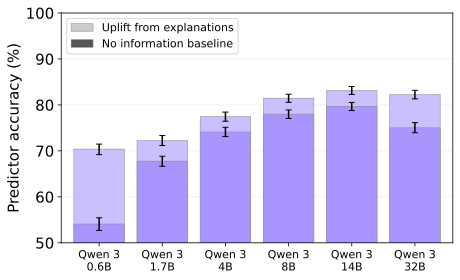

In [8]:
########################################################################
# Simulatability gain 
# Baseline of "No factual"
########################################################################
# experiments/cot/predictions_no_factual_baseline.parquet

import sys
sys.path.insert(0, '..')
from analysis_scripts.analyze_simulatability import analyze_simulatability_averaged
from src.schema import CounterfactualDatabase
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load parquet and run analysis
db = CounterfactualDatabase.load_parquet('../experiments/cot/predictions_no_factual_baseline.parquet')
first_record = db.records[0]
pred_with = first_record.counterfactual.predictor_response_with_explanation
predictor_indices = list(range(len(pred_with.predictor_names)))
df_nf = analyze_simulatability_averaged(db, predictor_indices, silent=True)

# Qwen name mapping and colors
name_dict = {
    'Qwen/Qwen3-0.6B_True': 'Qwen 3\n0.6B',
    'Qwen/Qwen3-1.7B_True': 'Qwen 3\n1.7B',
    'Qwen/Qwen3-4B_True': 'Qwen 3\n4B',
    'Qwen/Qwen3-8B_True': 'Qwen 3\n8B',
    'Qwen/Qwen3-14B_True': 'Qwen 3\n14B',
    'Qwen/Qwen3-32B_True': 'Qwen 3\n32B',
}
model_order = ['Qwen/Qwen3-0.6B_True', 'Qwen/Qwen3-1.7B_True', 'Qwen/Qwen3-4B_True',
               'Qwen/Qwen3-8B_True', 'Qwen/Qwen3-14B_True', 'Qwen/Qwen3-32B_True']

def lighten_color(hex_color, factor=0.4):
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    return f'#{int(r + (255 - r) * factor):02x}{int(g + (255 - g) * factor):02x}{int(b + (255 - b) * factor):02x}'

qwen_color = lighten_color('#7C5CFC', 0.35)  # Same as main figure
qwen_color_light = lighten_color(qwen_color, 0.4)

# Prepare data
df_nf['short_name'] = df_nf['model'].map(name_dict)
df_nf = df_nf[df_nf['model'].isin(model_order)].copy()
df_nf['model'] = pd.Categorical(df_nf['model'], categories=model_order, ordered=True)
df_nf = df_nf.sort_values('model').reset_index(drop=True)

# Figure parameters (matching main figure)
fig_width = 6.5
fig_height = 4
y_label_fontsize = 15
x_label_fontsize = 11
show_grid = True
show_error_bars = True

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

x_positions = range(len(df_nf))

# Plot WITH explanation accuracy (background - lighter bars)
if show_error_bars:
    yerr_with = [df_nf['with_explanation_accuracy'] - df_nf['with_ci_lower'],
                 df_nf['with_ci_upper'] - df_nf['with_explanation_accuracy']]
else:
    yerr_with = None
ax.bar(x_positions, df_nf['with_explanation_accuracy'],
       yerr=yerr_with, capsize=3 if show_error_bars else 0,
       color=qwen_color_light, edgecolor='#888888', linewidth=0.5)

# Plot WITHOUT explanation accuracy (foreground - darker bars)
if show_error_bars:
    yerr_without = [df_nf['without_explanation_accuracy'] - df_nf['without_ci_lower'],
                    df_nf['without_ci_upper'] - df_nf['without_explanation_accuracy']]
else:
    yerr_without = None
ax.bar(x_positions, df_nf['without_explanation_accuracy'],
       yerr=yerr_without, capsize=3 if show_error_bars else 0,
       color=qwen_color, edgecolor='#888888', linewidth=0.5)

if show_grid:
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='gray')
    ax.set_axisbelow(True)

ax.set_xticks(x_positions)
ax.set_xticklabels(df_nf['short_name'], rotation=0, ha='center', fontsize=x_label_fontsize)
ax.set_xlim(-0.6, len(df_nf) - 0.4)
ax.set_ylim(50, 100)

# Legend (same style as main figure)
legend_elements = [
    Patch(facecolor=lighten_color('#555555', 0.7), edgecolor='#888888', linewidth=0.5, label='Uplift from explanations'),
    Patch(facecolor='#555555', edgecolor='#888888', linewidth=0.5, label='No information baseline'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)
ax.tick_params(axis='y', labelsize=y_label_fontsize)
plt.ylabel('Predictor accuracy (%)', fontsize=y_label_fontsize)

plt.tight_layout()
plt.savefig('no_factual_accuracy_comparison.pdf', bbox_inches='tight')
print('Saved: no_factual_accuracy_comparison.pdf')

In [1]:
df

NameError: name 'df' is not defined

In [15]:
diff = df.sort_values('normalized_gain')[['normalized_gain', 'norm_gain_ci_lower','norm_gain_ci_upper']]
diff['av'] = ((df['norm_gain_ci_upper']-df['normalized_gain']) - (df['norm_gain_ci_lower']-df['normalized_gain']))/2
diff

df.sort_values('normalized_gain')[['normalized_gain', 'norm_gain_ci_lower','norm_gain_ci_upper']]

ValueError: cannot reindex on an axis with duplicate labels

#### Inference time compute

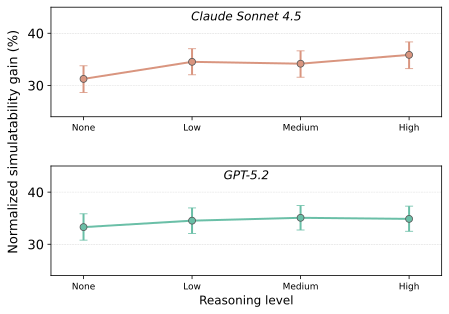

In [5]:
# Inference-time compute figure: Claude Sonnet 4.5 and GPT-5.2 at different thinking levels

# Model name mapping (internal -> display)
name_dict_itc = {
    "anthropic/claude-sonnet-4.5_none": "Claude Sonnet 4.5 (None)",
    "anthropic/claude-sonnet-4.5_low": "Claude Sonnet 4.5 (Low)",
    "anthropic/claude-sonnet-4.5_medium": "Claude Sonnet 4.5 (Medium)",
    "anthropic/claude-sonnet-4.5_high": "Claude Sonnet 4.5 (High)",
    "openai/gpt-5.2_none": "GPT-5.2 (None)",
    "openai/gpt-5.2_low": "GPT-5.2 (Low)",
    "openai/gpt-5.2_medium": "GPT-5.2 (Medium)",
    "openai/gpt-5.2_high": "GPT-5.2 (High)",
}

# Extract thinking level from model name
def get_thinking_level(model_name):
    if '_none' in model_name:
        return 'None'
    elif '_low' in model_name:
        return 'Low'
    elif '_medium' in model_name:
        return 'Medium'
    elif '_high' in model_name:
        return 'High'
    return 'Unknown'

# Family display names - use actual family names from data
family_display_names_itc = {
    'sonnet_itc': 'Claude Sonnet 4.5',
    'gpt_5_2_itc': 'GPT-5.2',
}

# Colors matching the main figure
model_colors = {
    'sonnet_itc': lighten_color('#C65D3B', 0.35),  # Claude orange
    'gpt_5_2_itc': lighten_color('#1B9D79', 0.35),  # GPT teal
}

# Marker styles
marker_styles = {
    'sonnet_itc': 'o',
    'gpt_5_2_itc': 'o',
}


df_sonnet = pd.read_csv("../experiments/dewi_upload/sonnet_itc_predictions_simulatability_averaged.csv")
df_sonnet['family'] = 'sonnet_itc'
df_gpt = pd.read_csv("../experiments/dewi_upload/gpt_5_2_itc_predictions_simulatability_averaged.csv")
df_gpt['family'] = 'gpt_5_2_itc'
df_extra = pd.read_csv("../experiments/dewi_upload/extra_three_ref_models_predictions_simulatability_averaged.csv")
df_gpt_none = df_extra[df_extra['model'] == 'openai/gpt-5.2_none'].copy()
df_gpt_none['family'] = 'gpt_5_2_itc'
df_gpt = pd.concat([df_gpt, df_gpt_none], ignore_index=True)

# Combine all ITC data
df_itc = pd.concat([df_sonnet, df_gpt], ignore_index=True)
df_itc['thinking_level'] = df_itc['model'].apply(get_thinking_level)
df_itc['short_name'] = df_itc['model'].map(name_dict_itc)

# Define thinking level order
thinking_order = ['None', 'Low', 'Medium', 'High']
df_itc['thinking_level'] = pd.Categorical(df_itc['thinking_level'], categories=thinking_order, ordered=True)
df_itc = df_itc.sort_values(['family', 'thinking_level']).reset_index(drop=True)

# Figure parameters - match VERSION 2
fig_width_itc = 6.5
fig_height_itc = 4.5
y_label_fontsize = 13
x_label_fontsize = 9
reasoning_level_font_size = 12
label_fontsize = 12
marker_size = 7
line_width = 2





# Create stacked subplots - NOT sharing x-axis so both can have labels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_width_itc, fig_height_itc), sharex=False)

# Plot Claude Sonnet 4.5 (top)
family = 'sonnet_itc'
df_family = df_itc[df_itc['family'] == family].copy().sort_values('thinking_level')
x_labels = df_family['thinking_level'].tolist()
x_positions = [thinking_order.index(level) for level in x_labels]
yerr_lower = df_family['normalized_gain'].values - df_family['norm_gain_ci_lower'].values
yerr_upper = df_family['norm_gain_ci_upper'].values - df_family['normalized_gain'].values

ax1.errorbar(
    x_positions,
    df_family['normalized_gain'].values,
    yerr=[yerr_lower, yerr_upper],
    marker=marker_styles[family],
    markersize=marker_size,
    linewidth=line_width,
    capsize=4,
    capthick=1.5,
    color=model_colors[family],
    markeredgecolor='#555555',
    markeredgewidth=0.8,
)
ax1.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='gray')
ax1.set_axisbelow(True)
ax1.set_ylim(24, 45)  # Match VERSION 2 y-axis
ax1.set_xlim(-0.3, len(thinking_order) - 0.7)
ax1.tick_params(axis='y', labelsize=y_label_fontsize)
ax1.text(0.5, 0.88, family_display_names_itc[family], ha='center', transform=ax1.transAxes, 
         fontsize=label_fontsize, fontstyle='italic')
# Add x-axis labels to top plot
ax1.set_xticks(range(len(thinking_order)))
ax1.set_xticklabels(thinking_order, fontsize=x_label_fontsize)

# Plot GPT-5.2 (bottom)
family = 'gpt_5_2_itc'
df_family = df_itc[df_itc['family'] == family].copy().sort_values('thinking_level')
x_labels = df_family['thinking_level'].tolist()
x_positions = [thinking_order.index(level) for level in x_labels]
yerr_lower = df_family['normalized_gain'].values - df_family['norm_gain_ci_lower'].values
yerr_upper = df_family['norm_gain_ci_upper'].values - df_family['normalized_gain'].values

ax2.errorbar(
    x_positions,
    df_family['normalized_gain'].values,
    yerr=[yerr_lower, yerr_upper],
    marker=marker_styles[family],
    markersize=marker_size,
    linewidth=line_width,
    capsize=4,
    capthick=1.5,
    color=model_colors[family],
    markeredgecolor='#555555',
    markeredgewidth=0.8,
)
ax2.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='gray')
ax2.set_axisbelow(True)
ax2.set_ylim(24, 45)  # Match VERSION 2 y-axis
ax2.set_xlim(-0.3, len(thinking_order) - 0.7)
ax2.tick_params(axis='y', labelsize=y_label_fontsize)
ax2.text(0.5, 0.88, family_display_names_itc[family], ha='center', transform=ax2.transAxes,
         fontsize=label_fontsize, fontstyle='italic')

# Set x-axis on bottom plot
ax2.set_xticks(range(len(thinking_order)))
ax2.set_xticklabels(thinking_order, fontsize=x_label_fontsize)
ax2.set_xlabel('Reasoning level', fontsize=reasoning_level_font_size)

# Shared y-axis label - match VERSION 2 positioning
fig.text(0.06, 0.55, 'Normalized simulatability gain (%)', va='center', ha='center', 
         rotation='vertical', fontsize=y_label_fontsize)

plt.tight_layout()
# Match VERSION 2 spacing for vertical alignment
plt.subplots_adjust(left=0.14, hspace=0.45)
plt.savefig('itc_results.pdf', bbox_inches='tight')

#### Breakdown by dataset

In [77]:
# do this manually to get the error bars right
families = ['gpt_5', 'claude_4_5', 'gemini_3', 'qwen_3', 'gemma_3']
all_data = []
for f in families:
    df_ = pd.read_parquet(f"../experiments/dewi_upload/{f}_predictions.parquet")
    df_['family'] = f
    all_data.append(df_)

# concat. 123247 rows
combined_df = pd.concat(all_data)

# filter 122205
answer_cols = ['original_reference_response_answer', 'counterfactual_reference_response_answer', 'counterfactual_predictor_response_with_explanation_answer', 'counterfactual_predictor_response_without_explanation_answer']
filtered_df = combined_df.dropna(subset=answer_cols)

# define nsg function
def normalised_sim_gain(df):
    """Create a standard function for bootstrapping."""
    with_correct = df['counterfactual_reference_response_answer'] == df['counterfactual_predictor_response_with_explanation_answer']
    without_correct = df['counterfactual_reference_response_answer'] == df['counterfactual_predictor_response_without_explanation_answer']
    
    result = df.assign(
        with_correct=with_correct,
        without_correct=without_correct
    ).groupby('original_dataset')[['with_correct', 'without_correct']].mean()
    
    result['nsg'] = (result['with_correct']-result['without_correct'])/(1 - result['without_correct'])
    return result

In [78]:
# clustered bootstrapping (optimized) - with multiple predictors exploded

def bootstrap_nsg_by_dataset(df, n_bootstrap=1000, confidence=0.95, cluster_col='original_question_idx'):
    """
    Clustered bootstrap for normalized simulatability gain by dataset.
    
    Explodes predictor_answers lists so each predictor is a separate observation.
    Resamples by cluster (original question) to handle correlation.
    """
    np.random.seed(42)

    df = df.copy().reset_index(drop=True)
    
    # Explode predictor_answers - each predictor becomes a separate row
    # First, create columns for the list data we need to explode together
    exploded_rows = []
    for idx, row in df.iterrows():
        with_answers = row['counterfactual_predictor_response_with_explanation_predictor_answers']
        without_answers = row['counterfactual_predictor_response_without_explanation_predictor_answers']
        ref_answer = row['counterfactual_reference_response_answer']
        dataset = row['original_dataset']
        q_idx = row[cluster_col]
        
        # Skip if lists are None or empty
        if with_answers is None or without_answers is None:
            continue
            
        n_predictors = min(len(with_answers), len(without_answers))
        for i in range(n_predictors):
            if with_answers[i] is not None and without_answers[i] is not None:
                exploded_rows.append({
                    'cluster': q_idx,
                    'dataset': dataset,
                    'with_correct': with_answers[i] == ref_answer,
                    'without_correct': without_answers[i] == ref_answer,
                })
    
    exploded_df = pd.DataFrame(exploded_rows)
    
    # Pre-compute cluster -> row indices mapping
    cluster_to_rows = exploded_df.groupby('cluster').indices
    clusters = np.array(list(cluster_to_rows.keys()))
    n_clusters = len(clusters)
    
    # Pre-extract columns as numpy arrays
    datasets = exploded_df['dataset'].values
    with_correct = exploded_df['with_correct'].values
    without_correct = exploded_df['without_correct'].values
    unique_datasets = exploded_df['dataset'].unique()

    # Point estimate
    point_est = exploded_df.groupby('dataset')[['with_correct', 'without_correct']].mean()
    point_est['nsg'] = (point_est['with_correct'] - point_est['without_correct']) / (1 - point_est['without_correct'])

    # Bootstrap storage
    boot_results = {dataset: [] for dataset in unique_datasets}

    for _ in tqdm(range(n_bootstrap)):
        # Resample cluster indices
        sampled_cluster_indices = np.random.randint(0, n_clusters, size=n_clusters)
        sampled_clusters = clusters[sampled_cluster_indices]
        
        # Get all row indices for sampled clusters
        row_indices = np.concatenate([cluster_to_rows[c] for c in sampled_clusters])
        
        # Extract values using indices
        boot_datasets = datasets[row_indices]
        boot_with = with_correct[row_indices]
        boot_without = without_correct[row_indices]
        
        # Calculate stats per dataset
        for dataset in unique_datasets:
            mask = boot_datasets == dataset
            if mask.sum() > 0:
                mean_with = boot_with[mask].mean()
                mean_without = boot_without[mask].mean()
                nsg = (mean_with - mean_without) / (1 - mean_without) if mean_without < 1 else 0
                boot_results[dataset].append(nsg)

    # Compute CIs
    alpha = 1 - confidence
    result = point_est.copy()
    result['nsg_ci_lower'] = [np.percentile(boot_results[d], alpha/2 * 100) for d in result.index]
    result['nsg_ci_upper'] = [np.percentile(boot_results[d], (1 - alpha/2) * 100) for d in result.index]

    return result

# Usage
bootstrap_results = bootstrap_nsg_by_dataset(filtered_df)
bootstrap_results


100%|██████████| 1000/1000 [00:38<00:00, 25.64it/s]


,with_correct,without_correct,nsg,nsg_ci_lower,nsg_ci_upper
dataset,,,,,
attrition,0.738325,0.609142,0.330513,0.305198,0.356100
bank_marketing,0.791042,0.667806,0.370977,0.351401,0.390177
breast_cancer_recurrence,0.744012,0.677102,0.207215,0.181359,0.237112
heart_disease,0.835616,0.761002,0.312194,0.276960,0.347792
income,0.776402,0.705989,0.239491,0.216193,0.262373
moral_machines,0.781754,0.767909,0.059654,0.039961,0.082369
pima_diabetes,0.871992,0.776192,0.428047,0.401654,0.452153


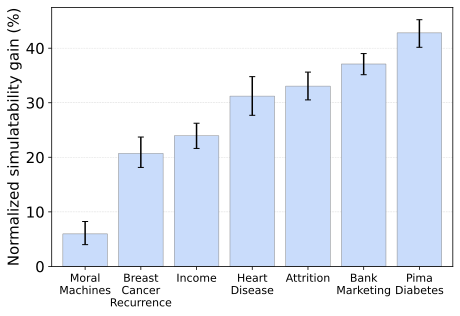

In [79]:
# Dataset name mapping (internal -> display)
dataset_name_dict = {
    'attrition': 'Attrition',
    'bank_marketing': 'Bank\nMarketing',
    'breast_cancer_recurrence': 'Breast\nCancer\nRecurrence',
    'heart_disease': 'Heart\nDisease',
    'income': 'Income',
    'moral_machines': 'Moral\nMachines',
    'pima_diabetes': 'Pima\nDiabetes',
}

# Figure parameters (matching main figure style)
fig_width_ds = 6.5
fig_height_ds = 4.5
y_label_fontsize = 15
x_label_fontsize = 11
bar_color = lighten_color('#7FAEF7') 
show_grid = True

# Helper function to lighten a hex color
def lighten_color(hex_color, factor=0.4):
    """Lighten a hex color by blending with white. factor=0 is original, factor=1 is white."""
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f'#{r:02x}{g:02x}{b:02x}'

# Lightened versions for the plot
lighten_factor = 0.3  # Adjust this: 0 = original, 1 = white
bar_color = lighten_color(bar_color, lighten_factor)

# Prepare data - sort by NSG (worst to best)
df_plot = bootstrap_results.copy()
df_plot['display_name'] = df_plot.index.map(dataset_name_dict)
df_plot = df_plot.sort_values('nsg').reset_index()

# Calculate error bars
yerr_lower = df_plot['nsg'] - df_plot['nsg_ci_lower']
yerr_upper = df_plot['nsg_ci_upper'] - df_plot['nsg']

# Create figure
fig, ax = plt.subplots(figsize=(fig_width_ds, fig_height_ds))

# Plot bars
ax.bar(
    range(len(df_plot)),
    df_plot['nsg'] * 100,  # Convert to percentage
    yerr=[yerr_lower * 100, yerr_upper * 100],
    capsize=3,
    color=bar_color,
    edgecolor='#888888',
    linewidth=0.5,
)

# Add horizontal grid lines
if show_grid:
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='gray')
    ax.set_axisbelow(True)

# Set x-axis ticks and labels
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['display_name'], rotation=0, ha='center', fontsize=x_label_fontsize)

# Set axis labels
ax.set_ylabel('Normalized simulatability gain (%)', fontsize=y_label_fontsize)
ax.tick_params(axis='y', labelsize=y_label_fontsize)

# Set x limits
ax.set_xlim(-0.6, len(df_plot) - 0.4)

plt.tight_layout()
plt.savefig('dataset_breakdown.pdf', bbox_inches='tight')

####

#### Egregious unfaithfulness

In [99]:
# create egregious
filtered_df['egregious'] = filtered_df.apply(lambda row: (len(set(row['counterfactual_predictor_response_with_explanation_predictor_answers']))==1) & (row['counterfactual_predictor_response_with_explanation_predictor_answers'][0]!=row['counterfactual_reference_response_answer']), axis=1)

/tmp/ipykernel_3621125/1577297720.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['egregious'] = filtered_df.apply(lambda row: (len(set(row['counterfactual_predictor_response_with_explanation_predictor_answers']))==1) & (row['counterfactual_predictor_response_with_explanation_predictor_answers'][0]!=row['counterfactual_reference_response_answer']), axis=1)


In [100]:
filtered_df.columns

Index(['original_dataset', 'original_question', 'original_question_prompt',
       'original_question_idx', 'original_ground_truth',
       'original_answer_first', 'original_description',
       'original_question_options', 'original_reference_response_cot',
       'original_reference_response_raw_response',
       'original_reference_response_parsed_response',
       'original_reference_response_answer',
       'original_reference_response_model_info_model',
       'original_reference_response_model_info_temperature',
       'original_reference_response_model_info_max_tokens',
       'original_reference_response_model_info_thinking',
       'original_reference_response_model_info_seed',
       'original_reference_response_model_info_additional_params',
       'original_reference_response_predictor_answers',
       'original_reference_response_predictor_names',
       'original_reference_response_input_tokens',
       'original_reference_response_reasoning_tokens',
       'original_re

In [101]:
# definition: egregious unfaithfulness: all three predictors are wrong in the with explanation case 

def bootstrap_egregious_by_model(df, n_bootstrap=1000, confidence=0.95, cluster_col='original_question_idx'):
    """
    Clustered bootstrap for egregious unfaithfulness rate by model.
    
    Egregious = all predictors agree AND they're all wrong.
    
    """
    np.random.seed(42)

    df = df.copy().reset_index(drop=True)

    # Pre-compute cluster -> row indices mapping
    cluster_to_rows = df.groupby(cluster_col).indices
    clusters = np.array(list(cluster_to_rows.keys()))
    n_clusters = len(clusters)
    
    # Pre-extract columns as numpy arrays
    models = df['original_reference_response_model_info_model'].values
    egregious = df['egregious'].values
    unique_models = df['original_reference_response_model_info_model'].unique()

    # Point estimate: egregious rate per model
    point_est = df.groupby('original_reference_response_model_info_model')['egregious'].mean().to_frame()
    point_est.columns = ['egregious_rate']

    # Bootstrap storage
    boot_results = {model: [] for model in unique_models}

    for _ in tqdm(range(n_bootstrap)):
        # Resample cluster indices
        sampled_cluster_indices = np.random.randint(0, n_clusters, size=n_clusters)
        sampled_clusters = clusters[sampled_cluster_indices]
        
        # Get all row indices for sampled clusters
        row_indices = np.concatenate([cluster_to_rows[c] for c in sampled_clusters])
        
        # Extract values using indices
        boot_models = models[row_indices]
        boot_egregious = egregious[row_indices]
        
        # Calculate egregious rate per model
        for model in unique_models:
            mask = boot_models == model
            if mask.sum() > 0:
                rate = boot_egregious[mask].mean()
                boot_results[model].append(rate)

    # Compute CIs
    alpha = 1 - confidence
    result = point_est.copy()
    result['ci_lower'] = [np.percentile(boot_results[m], alpha/2 * 100) for m in result.index]
    result['ci_upper'] = [np.percentile(boot_results[m], (1 - alpha/2) * 100) for m in result.index]

    return result

# Usage
egregious_results = bootstrap_egregious_by_model(filtered_df)
egregious_results

100%|██████████| 1000/1000 [00:18<00:00, 52.97it/s]


,egregious_rate,ci_lower,ci_upper
original_reference_response_model_info_model,,,
Qwen/Qwen3-0.6B,0.151148,0.141361,0.161577
Qwen/Qwen3-1.7B,0.152849,0.143299,0.162701
Qwen/Qwen3-14B,0.066143,0.060199,0.073000
Qwen/Qwen3-32B,0.074460,0.067588,0.081458
Qwen/Qwen3-4B,0.107706,0.100144,0.115808
Qwen/Qwen3-8B,0.076571,0.069900,0.083883
anthropic/claude-haiku-4.5,0.087647,0.080327,0.094649
anthropic/claude-opus-4.5,0.064189,0.057463,0.070861
anthropic/claude-sonnet-4.5,0.064724,0.058389,0.070843
